In [1]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = kagglehub.dataset_download("saidaminsaidaxmadov/chocolate-sales")

print("Path to dataset files:", path)


Path to dataset files: C:\Users\faris\.cache\kagglehub\datasets\saidaminsaidaxmadov\chocolate-sales\versions\2


In [2]:
files = os.listdir(path)
print(files)

['Chocolate Sales (2).csv', 'ChocolateSales.pbit', 'ChocolateSales.pbix', 'ChocolateSales.pdf']


In [3]:
df = pd.read_csv(os.path.join(path, files[0]))
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184


In [4]:
#LAB 3~ EDA

In [5]:
#LAB 4~ Data Quality & Preprocessing
df.dtypes

Sales Person     object
Country          object
Product          object
Date             object
Amount           object
Boxes Shipped     int64
dtype: object

In [6]:
#Convert incorrect dt
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Amount'] = df['Amount'].replace(r'[\$,]', '', regex=True)
df['Amount'] = pd.to_numeric(df['Amount'])

df.dtypes

Sales Person             object
Country                  object
Product                  object
Date             datetime64[ns]
Amount                  float64
Boxes Shipped             int64
dtype: object

In [7]:
#Handle Missing Values
#detect missing values
df.isna().sum() #NO MISSING VALUES WE ARE GOOODDDD

Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

In [8]:
#check for duplicates 
df.duplicated()[df.duplicated()==True] #we are good 

Series([], dtype: bool)

In [9]:
#we have no need of this code but I'm still using it since the labs have used it
df_missing = df.copy()
df_missing.loc[0:5, 'Amount'] = np.nan
df_missing.isna().sum()

Sales Person     0
Country          0
Product          0
Date             0
Amount           6
Boxes Shipped    0
dtype: int64

In [10]:
print("original: ", df.shape)
print("after cleaning: ", df_missing.shape)

original:  (3282, 6)
after cleaning:  (3282, 6)


In [11]:
df_missing.head(10)

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,NaN,180
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,NaN,94
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,NaN,91
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,NaN,342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,NaN,184
5,Van Tuxwell,India,Smooth Sliky Salty,2022-06-06,NaN,38
6,Oby Sorrel,UK,99% Dark & Pure,2022-01-25,13685.0,176
7,Gunar Cockshoot,Australia,After Nines,2022-03-24,3080.0,73
8,Jehu Rudeforth,New Zealand,50% Dark Bites,2022-04-20,3990.0,59
9,Brien Boise,Australia,99% Dark & Pure,2022-07-04,2835.0,102


In [12]:
#remove records (still dont need it for this dataset)
df_removed = df_missing.dropna()
df_removed.shape

(3276, 6)

In [13]:
df_removed.isna().sum()

Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

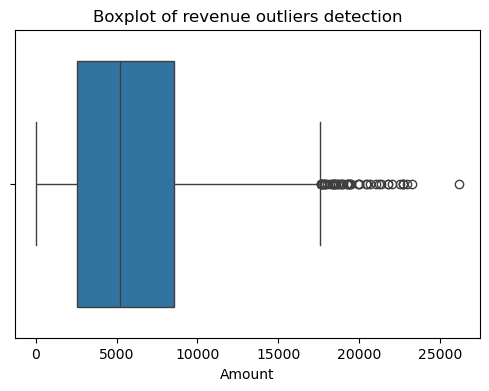

In [14]:
#Handle outliers
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Amount"])
plt.title("Boxplot of revenue outliers detection")
plt.show()

In [15]:
#Detect outliers using IQR
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Amount'] < lower) | (df['Amount'] > upper)]
outliers.head(15)


,Sales Person,Country,Product,Date,Amount,Boxes Shipped
66,Van Tuxwell,Australia,Organic Choco Syrup,2022-08-10,19453.00,14
135,Van Tuxwell,India,Organic Choco Syrup,2022-05-16,19929.00,174
212,Marney O'Breen,UK,Smooth Sliky Salty,2022-05-13,18991.00,88
434,Jan Morforth,New Zealand,Mint Chip Choco,2022-06-30,18340.00,285
543,Ches Bonnell,India,Peanut Butter Cubes,2022-01-27,22050.00,208
589,Curtice Advani,India,Smooth Sliky Salty,2022-04-19,19327.00,135
609,Jan Morforth,Australia,Mint Chip Choco,2022-02-22,17626.00,103
751,Rafaelita Blaksland,New Zealand,Eclairs,2022-02-07,19481.00,51
806,Brien Boise,India,85% Dark Bars,2022-08-09,18032.00,205
1008,Kaine Padly,UK,After Nines,2022-01-21,18697.00,176


In [16]:
df_no_outliers = df[(df['Amount'] >= lower) & (df['Amount'] <= upper)]
print("Original shape: ",df.shape)
print("After removing outliers: ",df_no_outliers.shape)

Original shape:  (3282, 6)
After removing outliers:  (3232, 6)


In [17]:
#=using percentile method to replace extreme values with percentile limits
lower_cap = df['Amount'].quantile(0.05)
upper_cap = df['Amount'].quantile(0.95)

df_capped = df.copy()
df_capped['Amount'] = df_capped['Amount'].clip(lower_cap, upper_cap)
df_capped.head(10)

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,5320.0,180
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,7896.0,94
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,4501.0,91
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,12726.0,342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,13685.0,184
5,Van Tuxwell,India,Smooth Sliky Salty,2022-06-06,5376.0,38
6,Oby Sorrel,UK,99% Dark & Pure,2022-01-25,13685.0,176
7,Gunar Cockshoot,Australia,After Nines,2022-03-24,3080.0,73
8,Jehu Rudeforth,New Zealand,50% Dark Bites,2022-04-20,3990.0,59
9,Brien Boise,Australia,99% Dark & Pure,2022-07-04,2835.0,102


In [18]:
#scalling data min-max normalization of data to fixed range of values between 0 and 1 
#preserves origiinal distribution shape and relaive ordering of values

In [19]:
df[["Amount", "Boxes Shipped"]].head()

,Amount,Boxes Shipped
0,5320.0,180
1,7896.0,94
2,4501.0,91
3,12726.0,342
4,13685.0,184


In [21]:
#scaling using MinMaxScaler (values between 0 and 1 only)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df[['Amount', 'Boxes Shipped']].copy()

df_scaled[['Amount', 'Boxes Shipped']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,Amount,Boxes Shipped
0,0.203066,0.230373
1,0.301522,0.119691
2,0.171763,0.115830
3,0.486127,0.438867
4,0.522780,0.235521


In [23]:
from sklearn.preprocessing import StandardScaler #positives and negatives

scaler = StandardScaler()
df_standarized = df[["Amount","Boxes Shipped"]].copy()

df_standarized[["Amount","Boxes Shipped"]] = scaler.fit_transform(df_standarized)

df_standarized.head()

,Amount,Boxes Shipped
0,-0.161686,0.123648
1,0.424660,-0.569868
2,-0.348106,-0.594061
3,1.524058,1.430038
4,1.742345,0.155904


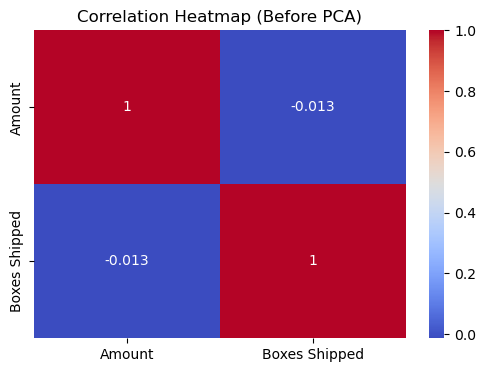

In [25]:
plt.figure(figsize=(6,4)) #application of PCA
sns.heatmap(df_standarized[['Amount','Boxes Shipped']].corr(), 
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

In [28]:
from sklearn.decomposition import PCA

X = df_standarized[['Amount','Boxes Shipped']]

pca = PCA(n_components = 2)
principal_components = pca.fit_transform(X)

print("Explained variance= ", pca.explained_variance_ratio_)

Explained variance=  [0.50657693 0.49342307]


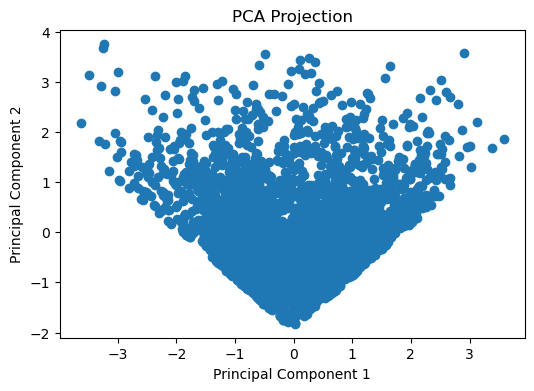

In [29]:
plt.figure(figsize=(6,4)) #PCA Projection shows the direction of maximum variance in the data
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()